In [ ]:
# Import OpenCV library for image processing
import cv2

# Import NumPy for numerical operations
import numpy as np

# Import Matplotlib to display images
import matplotlib.pyplot as plt

# Import OS library to work with folders
import os

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Store the dataset folder path

dataset_path="/content/drive/MyDrive/PetImages"

In [ ]:
# Read one image from the dataset

#imread is used to read a image from your computer and load into python

img=cv2.imread(dataset_path+"/Cat/0.jpg")

# Check whether image is loaded successfully

if img is None:
    print("Image Not Found")
else:
    print("Image Loaded Successfully")

Image Loaded Successfully


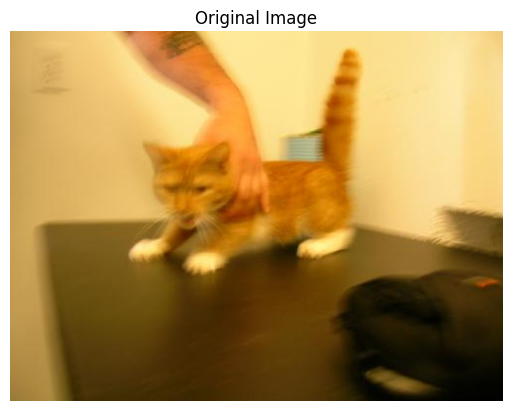

In [ ]:
# Convert image from BGR to RGB
# OpenCV reads images in BGR format
# Matplotlib displays images in RGB format

# cvtColor() → Convert Color. It changes one color format to another.
#img → The original image
# cv2.COLOR_BGR2RGB → Convert the image from BGR format to RGB format.

rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

# Display image

# imshow() → Image Show.
plt.imshow(rgb)

plt.title("Original Image")

plt.axis("off")

plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import os

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [ ]:
dataset = datasets.ImageFolder(
    root="/content/drive/MyDrive/PetImages",
    transform=transform
)

In [ ]:
print("Classes:", dataset.classes)
print("Class to Index:", dataset.class_to_idx)
print("Total Images:", len(dataset))

Classes: ['Cat', 'Dog']
Class to Index: {'Cat': 0, 'Dog': 1}
Total Images: 24999


In [ ]:
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

print("Training Images :", len(train_dataset))
print("Validation Images :", len(val_dataset))
print("Testing Images :", len(test_dataset))

Training Images : 19999
Validation Images : 2499
Testing Images : 2501


In [ ]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [ ]:
images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

Image Batch Shape : torch.Size([32, 3, 128, 128])
Label Batch Shape : torch.Size([32])


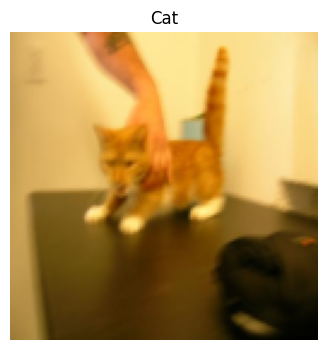

In [ ]:
image, label = dataset[0]

plt.figure(figsize=(4,4))
plt.imshow(image.permute(1, 2, 0))
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

In [ ]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(

            # Convolution Block 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Convolution Block 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Convolution Block 3
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)

        )

        self.fc_layers = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 16 * 16, 512),
            nn.ReLU(),

            nn.Linear(512, 2)

        )

    def forward(self, x):

        x = self.conv_layers(x)
        x = self.fc_layers(x)

        return x

In [ ]:
model = CNN().to(device)

print(model)

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=2, bias=True)
  )
)


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [ ]:
dummy = torch.randn(1, 3, 128, 128).to(device)

output = model(dummy)

print(output.shape)

torch.Size([1, 2])


In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
print(model)
print("\nLoss Function :", criterion)
print("\nOptimizer :", optimizer)

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=2, bias=True)
  )
)

Loss Function : CrossEntropyLoss()

Optimizer : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    fore

In [ ]:
epochs = 10

In [ ]:
train_loss = []
train_accuracy = []

val_loss = []
val_accuracy = []

In [ ]:
for epoch in range(epochs):

    # Training
    model.train()
    correct = total = train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    # Validation
    model.eval()
    correct = total = val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | "
          f"Val Acc: {val_acc:.2f}%")

In [ ]:
torch.save(model.state_dict(), "cnn_model.pth")

print("Model Saved Successfully!")